# LSTM Hybrid Training and Export

This notebook trains a TensorFlow hybrid sequence model, exports TFLite variants, and validates inference compatibility.

In [15]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf


In [16]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = "drive/MyDrive/Dev Team Project 2026/"
ARTIFACTS_DIR = os.path.join(BASE_DIR, "artifacts")
DATASET_PATH = os.path.join(ARTIFACTS_DIR, "lstm_dataset.npz")
META_PATH = os.path.join(ARTIFACTS_DIR, "lstm_dataset_meta.json")

print("TensorFlow version:", tf.__version__)
print("Artifacts dir:", ARTIFACTS_DIR)
print("Dataset path:", DATASET_PATH)
print("Meta path:", META_PATH)

TensorFlow version: 2.19.0
Artifacts dir: drive/MyDrive/Dev Team Project 2026/artifacts
Dataset path: drive/MyDrive/Dev Team Project 2026/artifacts/lstm_dataset.npz
Meta path: drive/MyDrive/Dev Team Project 2026/artifacts/lstm_dataset_meta.json


## Data Loading

Load dataset artifacts and metadata from the configured project path.

In [18]:
if not os.path.isfile(DATASET_PATH):
    raise FileNotFoundError(f"Missing dataset: {DATASET_PATH}")
if not os.path.isfile(META_PATH):
    raise FileNotFoundError(f"Missing metadata: {META_PATH}")

data = np.load(DATASET_PATH, allow_pickle=True)
with open(META_PATH, "r", encoding="utf-8") as f:
    meta = json.load(f)

print("Keys:", data.files)
for key in data.files:
    print(f"{key}: shape={data[key].shape}, dtype={data[key].dtype}")
print("Class names:", meta.get("class_names", []))

Keys: ['X_train_lstm', 'X_val_lstm', 'y_train_lstm', 'y_val_lstm']
X_train_lstm: shape=(1576, 10, 126), dtype=float32
X_val_lstm: shape=(395, 10, 126), dtype=float32
y_train_lstm: shape=(1576,), dtype=int64
y_val_lstm: shape=(395,), dtype=int64
Class names: ['3aslema', '3ayla', '5adamet', '5al-3am', '5mis', '5ou', 'a7ad', 'assam', 'baladya', 'banka', 'barnamjk', 'bent', 'bou', 'bousta', 'car', 'chabeb', 'cv', 'dar', 'demande', 'eben', 'enti', 'erb3a', 'jad', 'jadda', 'jom3a', 'karhba', 'labes', 'louage', 'lyoum', 'ma7kma', 'mar2a', 'mar7ba', 'metro', 'mostawsaf', 'n3awnek', 'nekteblk', 'non', 'o5t', 'om', 'oui', 'radio', 'sbitar', 'se7a', 'sebt', 'siye7a', 't7eb', 'ta3lim', 'ta3raf', 'ta9ra', 'taxi', 'telvza', 'tfol', 'tha9afa', 'thleth', 'thnin', 'train', 'wzara']


In [19]:
X_train_lstm = data["X_train_lstm"]
X_val_lstm = data["X_val_lstm"]
y_train_lstm = data["y_train_lstm"]
y_val_lstm = data["y_val_lstm"]

num_classes = int(meta["num_classes"])
num_features = int(meta["num_features"])

print("Before duplication")
print("Train shape:", X_train_lstm.shape, y_train_lstm.shape)
print("Val shape:", X_val_lstm.shape, y_val_lstm.shape)
print("Feature count:", num_features)
print("Class count:", num_classes)

Before duplication
Train shape: (1576, 10, 126) (1576,)
Val shape: (395, 10, 126) (395,)
Feature count: 126
Class count: 57


In [20]:
def double_sequence_frames(X, target_frames=20):
    """
    Duplicate each frame once along the time axis.
    Example: [1,2,3] -> [1,1,2,2,3,3]

    If resulting length differs from target_frames, the output is cropped
    or right-padded using the last frame.
    """
    doubled = np.repeat(X, 2, axis=1)

    if doubled.shape[1] > target_frames:
        doubled = doubled[:, :target_frames, :]
    elif doubled.shape[1] < target_frames:
        pad_len = target_frames - doubled.shape[1]
        last_frame = doubled[:, -1:, :]
        pad = np.repeat(last_frame, pad_len, axis=1)
        doubled = np.concatenate([doubled, pad], axis=1)

    return doubled

TARGET_SEQ_LEN = 20
X_train_lstm = double_sequence_frames(X_train_lstm, target_frames=TARGET_SEQ_LEN)
X_val_lstm = double_sequence_frames(X_val_lstm, target_frames=TARGET_SEQ_LEN)

meta["seq_len"] = TARGET_SEQ_LEN

print("After duplication")
print(f"X_train_lstm shape: {X_train_lstm.shape}")
print(f"X_val_lstm shape: {X_val_lstm.shape}")
print(f"Updated seq_len in metadata: {meta['seq_len']}")

After duplication
X_train_lstm shape: (1576, 20, 126)
X_val_lstm shape: (395, 20, 126)
Updated seq_len in metadata: 20


## Sequence Preparation

Duplicate frames to reach `seq_len=20`, then build TensorFlow datasets for training/validation.

In [21]:
X_train = X_train_lstm.astype(np.float32)
X_val = X_val_lstm.astype(np.float32)
y_train = y_train_lstm.astype(np.int32)
y_val = y_val_lstm.astype(np.int32)

BATCH_SIZE = 64

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train), seed=SEED).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Input tensor shape:", X_train.shape)

Train batches: 25
Val batches: 7
Input tensor shape: (1576, 20, 126)


## Model Definition and Training


In [22]:
def build_lstm_hybrid(input_shape, num_classes, dropout=0.3):
    inputs = tf.keras.Input(shape=input_shape, name="input")

    x = tf.keras.layers.LSTM(64, return_sequences=True, use_cudnn=False, unroll=True, name="lstm1")(inputs)
    x = tf.keras.layers.LSTM(128, return_sequences=True, use_cudnn=False, unroll=True, name="lstm2")(x)
    x = tf.keras.layers.LSTM(128, return_sequences=False, use_cudnn=False, unroll=True, name="lstm3")(x)

    x = tf.keras.layers.Dense(64, activation="relu", name="fc1")(x)
    x = tf.keras.layers.Dropout(dropout, name="dropout1")(x)

    x = tf.keras.layers.Dense(32, activation="relu", name="fc2")(x)
    x = tf.keras.layers.Dropout(dropout, name="dropout2")(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="output")(x)
    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="LSTMHybridTF")
    return model

seq_len = int(meta["seq_len"])
model = build_lstm_hybrid(input_shape=(seq_len, num_features), num_classes=num_classes, dropout=0.3)

model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

model.summary()

Model: "LSTMHybridTF"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 20, 126)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm1 (LSTM)                    │ (None, 20, 64)         │        48,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm2 (LSTM)                    │ (None, 20, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm3 (LSTM)                    │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 57)             │         1,881 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291,513 (1.11 MB)

 Trainable params: 291,513 (1.11 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
NUM_EPOCHS = 100

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=15,
        restore_best_weights=True,
        mode="max",
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=NUM_EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 67s 1s/step - accuracy: 0.0628 - loss: 3.8633 - val_accuracy: 0.2228 - val_loss: 3.4913
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1713 - loss: 3.3370 - val_accuracy: 0.3114 - val_loss: 2.7996
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2513 - loss: 2.8584 - val_accuracy: 0.3570 - val_loss: 2.3050
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3109 - loss: 2.5278 - val_accuracy: 0.4430 - val_loss: 2.0270
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3629 - loss: 2.2586 - val_accuracy: 0.5392 - val_loss: 1.7386
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3985 - loss: 2.0548 - val_accuracy: 0.5671 - val_loss: 1.5597
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4467 - loss: 1.9056 - val_accuracy: 0.6025 - val_loss: 1.3757
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4905 - loss: 1.7394 - val_accuracy: 0.6

Validation accuracy (TensorFlow): 0.9823
Validation predictions sample: [32 12 48 10 12  9 56 11 30 53 36 19 13 26 37 40 12 28 51 11]


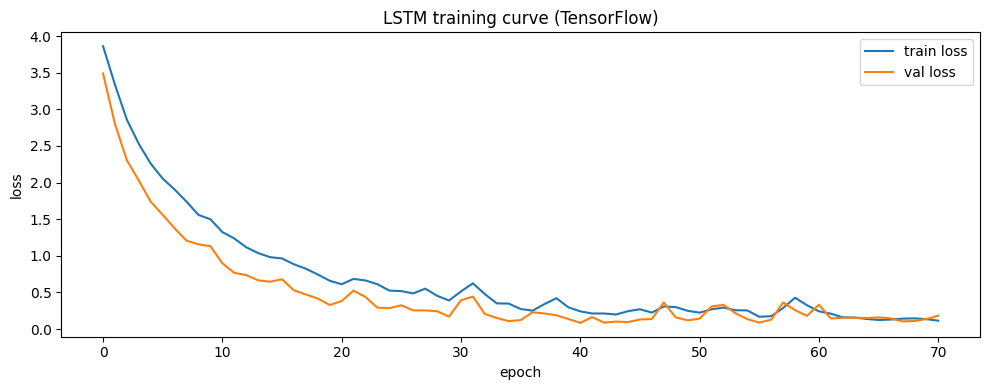

In [24]:
val_probs = model.predict(X_val, verbose=0)
val_predictions = np.argmax(val_probs, axis=1)
val_acc = (val_predictions == y_val).mean()

print(f"Validation accuracy (TensorFlow): {val_acc:.4f}")
print("Validation predictions sample:", val_predictions[:20])

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.title("LSTM training curve (TensorFlow)")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
TF_MODEL_PATH = os.path.join(ARTIFACTS_DIR, "lstmhybrid_tf.keras")
TF_SAVEDMODEL_DIR = os.path.join(ARTIFACTS_DIR, "tf_model_dir", "lstmhybrid_tf")

os.makedirs(os.path.dirname(TF_MODEL_PATH), exist_ok=True)
os.makedirs(TF_SAVEDMODEL_DIR, exist_ok=True)

model.save(TF_MODEL_PATH)
model.export(TF_SAVEDMODEL_DIR)

print(f"Keras model saved to: {TF_MODEL_PATH}")
print(f"SavedModel exported to: {TF_SAVEDMODEL_DIR}")

Saved artifact at 'drive/MyDrive/Dev Team Project 2026/artifacts/tf_model_dir/lstmhybrid_tf'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 126), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 57), dtype=tf.float32, name=None)
Captures:
  135615387590608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387590800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387586576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387590032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387585424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387587728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387591760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387586000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615264464080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615264461584: TensorSpec(shape=(), 

## Export Artifacts

Save Keras and SavedModel formats, then export TFLite variants:
- builtins-only (`model_builtin_float32.tflite`)
- Flex-enabled float32/float16 fallback files

In [26]:
tflite_out_dir = os.path.join(ARTIFACTS_DIR, "tf_model_dir", "lstmhybrid_tf")
os.makedirs(tflite_out_dir, exist_ok=True)

builtin_path = os.path.join(tflite_out_dir, "model_builtin_float32.tflite")
float32_path = os.path.join(tflite_out_dir, "model_float32.tflite")
float16_path = os.path.join(tflite_out_dir, "model_float16.tflite")

builtin_ok = False
try:
    converter_builtin = tf.lite.TFLiteConverter.from_keras_model(model)
    converter_builtin.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
    converter_builtin._experimental_lower_tensor_list_ops = True
    tflite_builtin = converter_builtin.convert()
    with open(builtin_path, "wb") as f:
        f.write(tflite_builtin)
    builtin_ok = True
except Exception as e:
    print("Builtins-only export failed:", e)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter._experimental_lower_tensor_list_ops = False
tflite_model = converter.convert()
with open(float32_path, "wb") as f:
    f.write(tflite_model)

converter_fp16 = tf.lite.TFLiteConverter.from_keras_model(model)
converter_fp16.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS,
    tf.lite.OpsSet.SELECT_TF_OPS,
]
converter_fp16._experimental_lower_tensor_list_ops = False
converter_fp16.optimizations = [tf.lite.Optimize.DEFAULT]
converter_fp16.target_spec.supported_types = [tf.float16]
tflite_model_fp16 = converter_fp16.convert()
with open(float16_path, "wb") as f:
    f.write(tflite_model_fp16)

print("TFLite exports complete:")
if builtin_ok:
    print(f"- {builtin_path}")
else:
    print("- builtins-only export not generated")
print(f"- {float32_path}")
print(f"- {float16_path}")

Saved artifact at '/tmp/tmp7vmfkb2d'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 20, 126), dtype=tf.float32, name='input')
Output Type:
  TensorSpec(shape=(None, 57), dtype=tf.float32, name=None)
Captures:
  135615387590608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387590800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387586576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387590032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387585424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387587728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387591760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615387586000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615264464080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615264461584: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135615264462160: TensorS

In [27]:
tf_dir = os.path.join(ARTIFACTS_DIR, "tf_model_dir", "lstmhybrid_tf")
for root, dirs, files in os.walk(tf_dir):
    level = root.replace(tf_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files:
        filepath = os.path.join(root, file)
        size_kb = os.path.getsize(filepath) / 1024
        print(f"{indent}  {file} ({size_kb:.1f} KB)")

lstmhybrid_tf/
  model_float32.tflite (1306.5 KB)
  model_float16.tflite (738.9 KB)
  saved_model.pb (353.7 KB)
  fingerprint.pb (0.1 KB)
  model_builtin_float32.tflite (1306.5 KB)
  variables/
    variables.index (2.1 KB)
    variables.data-00000-of-00001 (2281.2 KB)
  assets/


## TFLite Validation

Run a quick validation pass using the exported TFLite model before deploying to real-time inference.

In [28]:
# Test TFLite model on validation data
import os
import numpy as np
import tensorflow as tf

# Prefer builtins-only model, then fallback to Flex-enabled variants.
candidates = [
    os.path.join(ARTIFACTS_DIR, "tf_model_dir", "lstmhybrid_tf", "model_builtin_float32.tflite"),
    os.path.join(ARTIFACTS_DIR, "tf_model_dir", "lstmhybrid_tf", "model_float32.tflite"),
    os.path.join(ARTIFACTS_DIR, "tf_model_dir", "lstmhybrid_tf", "model_float16.tflite"),
]

tflite_test_path = None
for p in candidates:
    if os.path.isfile(p):
        tflite_test_path = p
        break

if tflite_test_path is None:
    raise FileNotFoundError("No TFLite model found. Run the export cell first.")

interpreter = tf.lite.Interpreter(model_path=tflite_test_path)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()[0]
output_details = interpreter.get_output_details()[0]

print("Using TFLite model:", tflite_test_path)
print("Input details:", input_details)
print("Output details:", output_details)

preds = []
for i in range(X_val.shape[0]):
    x = X_val[i : i + 1].astype(input_details["dtype"])

    interpreter.set_tensor(input_details["index"], x)
    interpreter.invoke()

    out = interpreter.get_tensor(output_details["index"])
    pred = int(np.argmax(out, axis=1)[0])
    preds.append(pred)

preds = np.array(preds, dtype=np.int32)
acc = float((preds == y_val).mean())

print(f"TFLite validation accuracy: {acc:.4f}")
print("Sample predictions:", preds[:20])
print("Sample labels:", y_val[:20])

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Using TFLite model: drive/MyDrive/Dev Team Project 2026/artifacts/tf_model_dir/lstmhybrid_tf/model_builtin_float32.tflite
Input details: {'name': 'serving_default_input:0', 'index': 0, 'shape': array([  1,  20, 126], dtype=int32), 'shape_signature': array([ -1,  20, 126], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
Output details: {'name': 'StatefulPartitionedCall_1:0', 'index': 1123, 'shape': array([ 1, 57], dtype=int32), 'shape_signature': array([-1, 57], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}
TFLite validation accuracy: 0.9823
Sample predictions: [32 12 48 10 12  9 56 11 30 53 36 19 13 26 37 40 12 28 51 11]
Sam